In [ ]:
import os
import torch
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import jax
import jax.numpy as jnp
from jax import config
config.update("jax_enable_x64", True) 

from pdetransformer.core.mixed_channels import PDETransformer

# 1. Setup & Data Loading
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

DATA_DIR = Path.cwd().parent.parent / "data" / "darcy_flow_data" 
FILE_PATH = DATA_DIR / "2D_DarcyFlow_beta10.0_Train_Scale1.hdf5"

with h5py.File(FILE_PATH, 'r') as f:
    fine_x_coords = np.array(f['x-coordinate'][:])
    fine_y_coords = np.array(f['y-coordinate'][:])
    
    # Load only Sample 0 for the ablation test
    a_sample = np.array(f['a_flat'][0])
    a_x_sample = np.array(f['a_x_flat'][0])
    a_y_sample = np.array(f['a_y_flat'][0])
    u_sim_sample = np.array(f['u_flat'][0])

fine_nx, fine_ny = len(fine_x_coords), len(fine_y_coords)
dx = fine_x_coords[1] - fine_x_coords[0]
dy = fine_y_coords[1] - fine_y_coords[0]

print(f"Loaded Sample 0. Grid: {fine_nx}x{fine_ny}. dx={dx:.4f}, dy={dy:.4f}")

# 2. Load the Pre-trained Foundation Model
# The 'mc-s' (Mixed Channel - Small) variant expects 2 input channels.
fm_model = PDETransformer.from_pretrained('thuerey-group/pde-transformer', subfolder='mc-s').to(device)
fm_model.eval()
print("PDE-Transformer Loaded.")

/home/tanki/projects/jax_env/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Using device: cuda
Loaded Sample 0. Grid: 128x128. dx=0.0078, dy=0.0078


/home/tanki/projects/jax_env/lib/python3.12/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


PDE-Transformer Loaded.


In [2]:
# 1. Prepare Inputs for the Foundation Model
a_tensor = torch.tensor(a_sample.reshape(fine_nx, fine_ny), dtype=torch.float32)
a_tensor = a_tensor.unsqueeze(0).unsqueeze(0).to(device)

beta = 10.0
f_tensor = torch.full_like(a_tensor, beta)

# Concatenate to 2 channels to satisfy the model's structural requirement. 
input_tensor = torch.cat([a_tensor, f_tensor], dim=1) 

# 2. Register the Forward Hook
latent_features = {}

def get_features_hook(module, args):
    # args[0] captures the input tensor right before it enters the final layer
    latent_features['phi'] = args[0].detach()

# Hook into the exact layer before it collapses the 96 hidden channels down to the outputs
hook_handle = fm_model.model.final_layer.out_proj.register_forward_pre_hook(get_features_hook)

print("Running forward pass to extract latents...")
with torch.no_grad():
    _ = fm_model(input_tensor)

hook_handle.remove()

# 3. Clean and Bridge to JAX
if 'phi' in latent_features:
    extracted_tensor = latent_features['phi']
    
    # Safely reshape the extracted 96-channel latents back to the 128x128 grid
    if extracted_tensor.ndim == 3: # Format: (Batch, N_points, Channels)
        channels = extracted_tensor.shape[-1]
        features_np = extracted_tensor.squeeze(0).cpu().numpy()
        f_eval_jax = features_np.reshape(fine_nx, fine_ny, channels)
    elif extracted_tensor.ndim == 4: # Format: (Batch, Channels, X, Y)
        features_np = extracted_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()
        f_eval_jax = features_np
        
    print(f"Extraction successful! Latent Feature Grid Shape: {f_eval_jax.shape}")
else:
    raise ValueError("Hook failed to capture latent features.")

Running forward pass to extract latents...
Extraction successful! Latent Feature Grid Shape: (32, 32, 192)


Bridging to JAX and aligning spatial resolutions...
Assembling Matrix A and Target b...
Condition Number of (A^T A + lambda I): 1.2603e+13
Solving for weights W...
Direct solve complete!

Relative L2 Error: 99.53%


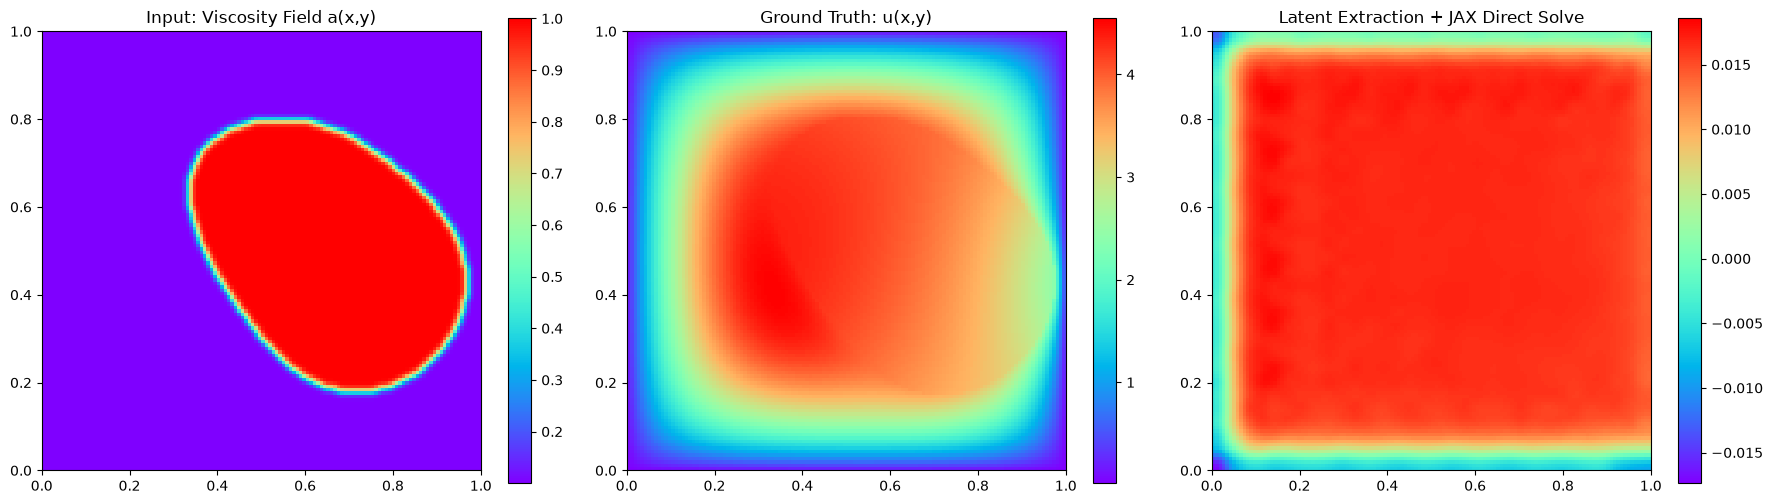

In [4]:
import jax
import jax.numpy as jnp

print("Bridging to JAX and aligning spatial resolutions...")

# 1. Convert raw extracted latents to JAX array
phi_grid_raw = jnp.array(f_eval_jax, dtype=jnp.float64) 
channels = phi_grid_raw.shape[-1]

# 2. Resample the (32, 32) latent grid to match the target (128, 128) physical grid
# Using bicubic interpolation ensures C1/C2 smoothness for spatial differentiation
phi_grid = jax.image.resize(phi_grid_raw, (fine_nx, fine_ny, channels), method='bicubic')

# 3. Compute Spatial Derivatives via Finite Differences on the 128x128 Latent Grid
phi_x = jnp.gradient(phi_grid, dx, axis=0)
phi_y = jnp.gradient(phi_grid, dy, axis=1)
phi_xx = jnp.gradient(phi_x, dx, axis=0)
phi_yy = jnp.gradient(phi_y, dy, axis=1)

# Flatten back to (16384, channels) for matrix assembly
phi_flat = phi_grid.reshape(-1, channels)
phi_x_flat = phi_x.reshape(-1, channels)
phi_y_flat = phi_y.reshape(-1, channels)
phi_xx_flat = phi_xx.reshape(-1, channels)
phi_yy_flat = phi_yy.reshape(-1, channels)

# 4. Prepare Physics Fields
a_flat = a_sample.reshape(-1, 1)
ax_flat = a_x_sample.reshape(-1, 1)
ay_flat = a_y_sample.reshape(-1, 1)

# 5. Assemble Matrix A (PDE Constraints)
print("Assembling Matrix A and Target b...")
# Residual: -(a_x * u_x + a_y * u_y + a * (u_xx + u_yy)) = f
A_pde = -(ax_flat * phi_x_flat + ay_flat * phi_y_flat + a_flat * (phi_xx_flat + phi_yy_flat))
b_pde = jnp.full((A_pde.shape[0],), beta)

# 6. Assemble Matrix A (Boundary Constraints)
X_grid, Y_grid = np.meshgrid(fine_x_coords, fine_y_coords, indexing='ij')
X_flat, Y_flat = X_grid.flatten(), Y_grid.flatten()
x_min, x_max = fine_x_coords[0], fine_x_coords[-1]
y_min, y_max = fine_y_coords[0], fine_y_coords[-1]

tol = 1e-6
boundary_mask = (np.abs(X_flat - x_min) < tol) | (np.abs(X_flat - x_max) < tol) | \
                (np.abs(Y_flat - y_min) < tol) | (np.abs(Y_flat - y_max) < tol)

matrix_bc_weight = 1e2
A_bc = phi_flat[boundary_mask] * jnp.sqrt(matrix_bc_weight)
b_bc = jnp.zeros((A_bc.shape[0],))

# 7. Solve the Linear System (Pseudoinverse)
A_full = jnp.vstack([A_pde, A_bc])
b_full = jnp.concatenate([b_pde, b_bc])

tik_reg_fixed = 5e-5
AtA = A_full.T @ A_full + tik_reg_fixed * jnp.eye(channels)
Atb = A_full.T @ b_full

cond_number = jnp.linalg.cond(AtA)
print(f"Condition Number of (A^T A + lambda I): {cond_number:.4e}")

print("Solving for weights W...")
w_solve = jax.scipy.linalg.solve(AtA, Atb)
print("Direct solve complete!")

# 8. Evaluate and Visualize
u_pred_flat = phi_flat @ w_solve
u_pred_2d = u_pred_flat.reshape(fine_nx, fine_ny)
u_sim_2d = u_sim_sample.reshape(fine_nx, fine_ny)
a_sample_2d = a_sample.reshape(fine_nx, fine_ny)

err = jnp.linalg.norm(u_pred_flat - u_sim_sample.flatten()) / jnp.linalg.norm(u_sim_sample.flatten())
print(f"\nRelative L2 Error: {err * 100:.2f}%")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ext = [0.0, 1.0, 0.0, 1.0]

im0 = axes[0].imshow(a_sample_2d.T, origin='lower', extent=ext, cmap='rainbow')
axes[0].set_title("Input: Viscosity Field a(x,y)")
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(u_sim_2d.T, origin='lower', extent=ext, cmap='rainbow')
axes[1].set_title("Ground Truth: u(x,y)")
fig.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(u_pred_2d.T, origin='lower', extent=ext, cmap='rainbow')
axes[2].set_title("Latent Extraction + JAX Direct Solve")
fig.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

Testing Foundation Model Expressivity (Supervised Fit)...
Running least squares regression against ground truth...
Supervised Fit Relative L2 Error: 5.61%


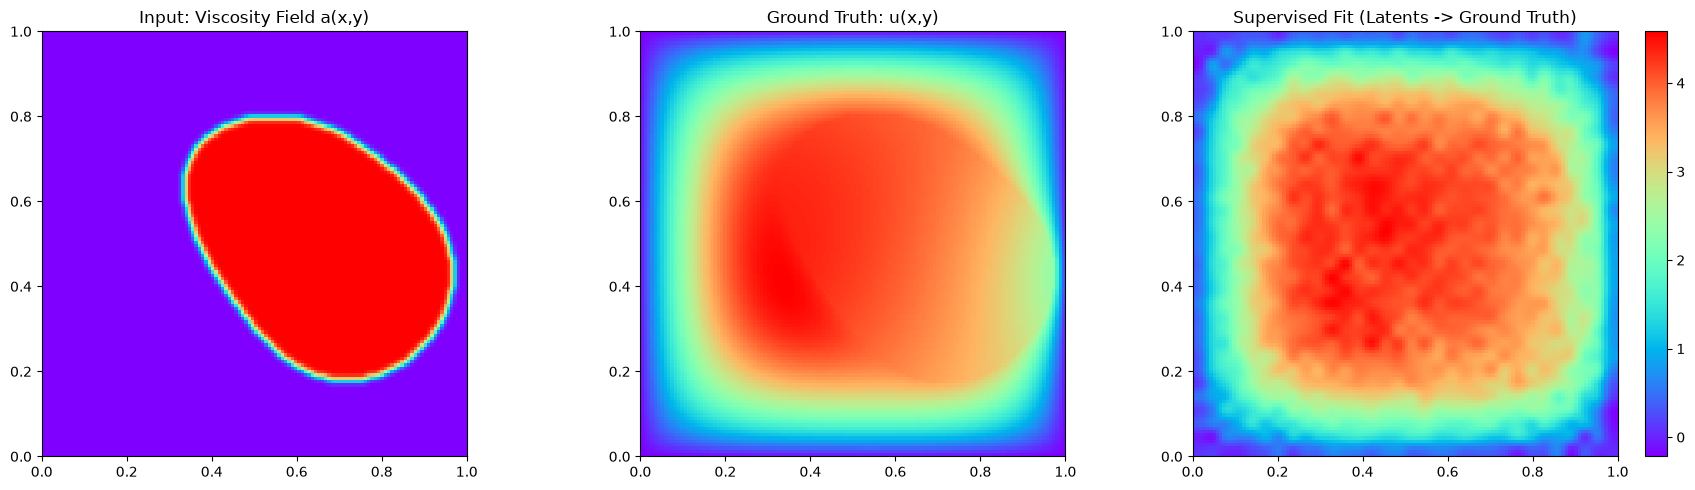

In [5]:
import jax.numpy as jnp
import matplotlib.pyplot as plt

print("Testing Foundation Model Expressivity (Supervised Fit)...")

# 1. Convert to JAX array and resize to 128x128 (same as before)
phi_grid_raw = jnp.array(f_eval_jax, dtype=jnp.float64) 
channels = phi_grid_raw.shape[-1]
phi_grid = jax.image.resize(phi_grid_raw, (fine_nx, fine_ny, channels), method='bicubic')

# 2. Flatten for matrix math
phi_flat = phi_grid.reshape(-1, channels)
u_sim_flat = u_sim_sample.flatten()

# 3. SUPERVISED DATA SOLVE: Can Phi map directly to the ground truth?
# We bypass the PDE, derivatives, and boundaries entirely.
print("Running least squares regression against ground truth...")
w_data_solve, residuals, rank, s = jnp.linalg.lstsq(phi_flat, u_sim_flat)

# 4. Generate the prediction
u_data_pred_flat = phi_flat @ w_data_solve
u_data_pred_2d = u_data_pred_flat.reshape(fine_nx, fine_ny)
u_sim_2d = u_sim_sample.reshape(fine_nx, fine_ny)

# 5. Evaluate
err = jnp.linalg.norm(u_data_pred_flat - u_sim_flat) / jnp.linalg.norm(u_sim_flat)
print(f"Supervised Fit Relative L2 Error: {err * 100:.2f}%")

# 6. Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ext = [0.0, 1.0, 0.0, 1.0]

axes[0].imshow(a_sample.reshape(fine_nx, fine_ny).T, origin='lower', extent=ext, cmap='rainbow')
axes[0].set_title("Input: Viscosity Field a(x,y)")

axes[1].imshow(u_sim_2d.T, origin='lower', extent=ext, cmap='rainbow')
axes[1].set_title("Ground Truth: u(x,y)")

im2 = axes[2].imshow(u_data_pred_2d.T, origin='lower', extent=ext, cmap='rainbow')
axes[2].set_title("Supervised Fit (Latents -> Ground Truth)")
fig.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()